In [65]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

output_path = Path('.').parent / '../output'  
csv_file_path_racing_line = output_path / 'racing_line_coordinates.csv'


In [66]:
import pandas as pd
# Load the racing line coordinates from the CSV file
racing_line_df = pd.read_csv(csv_file_path_racing_line)
racing_line_df

,x_world,y_world
0,0.560000,0.160000
1,0.284729,0.110000
2,0.009617,0.059617
3,-0.228963,0.021037
4,-0.499663,-0.040000
...,...,...
95,1.773216,0.110000
96,1.497945,0.160000
97,1.201963,0.160000
98,0.905982,0.160000


In [67]:
racing_track = racing_line_df.to_numpy()
racing_track

array([[ 0.56      ,  0.16      ],
       [ 0.284729  ,  0.11      ],
       [ 0.00961675,  0.05961675],
       [-0.22896323,  0.02103677],
       [-0.49966264, -0.04      ],
       [-0.76470182, -0.11470182],
       [-1.02949397, -0.19      ],
       [-1.28405429, -0.29      ],
       [-1.52437572, -0.42437572],
       [-1.77246425, -0.54      ],
       [-2.0063139 , -0.69      ],
       [-2.24011564, -0.84011564],
       [-2.44940629, -1.04940629],
       [-2.65869694, -1.25869694],
       [-2.83263226, -1.48263226],
       [-2.97121223, -1.72121223],
       [-3.07443686, -1.97443686],
       [-3.14      , -2.2432614 ],
       [-3.19      , -2.5185324 ],
       [-3.19      , -2.81451408],
       [-3.24      , -3.08978508],
       [-3.19      , -3.36505608],
       [-3.14      , -3.64032708],
       [-3.09      , -3.91559808],
       [-2.99      , -4.1701584 ],
       [-2.86545015, -4.41454985],
       [-2.69151484, -4.63848516],
       [-2.51757953, -4.86242047],
       [-2.30828888,

In [68]:
# Uses previous and next coords to calculate the radius of the curve
# so you need to pass a list with form [[x1,y1],[x2,y2],[x3,y3]]
# Input 3 coords [[x1,y1],[x2,y2],[x3,y3]]
from typing import List

def wrapping_rolling_average(data_list: List[float], window_size: int) -> List[float]:
    """
    Calculates a rolling average on a list of data that wraps around,
    like on a racetrack.
    
    Args:
        data_list: The list of numbers to smooth (e.g., your radii).
        window_size: The number of points to include in the average. Must be odd.

    Returns:
        A new list containing the smoothed data.
    """
    if not window_size % 2:
        raise ValueError("Window size must be an odd number.")
    if len(data_list) < window_size:
        # Not enough data to smooth, return the original list
        return data_list
        
    # Convert to a pandas Series and handle any lingering infs/nans
    # Your combined interpolation is fine here.
    data_series = pd.Series(data_list).replace(np.inf, np.nan).interpolate(method='linear')
    # Fill any remaining NaNs at the start/end after interpolation
    data_series.bfill(inplace=True)
    data_series.ffill(inplace=True)
    
    # Create a temporary, extended series to handle the wrap-around
    half_window = window_size // 2
    wrapped_data = pd.concat([
        data_series.iloc[-half_window:], 
        data_series, 
        data_series.iloc[:half_window]
    ])
    
    # Calculate the rolling average on the wrapped data using a CENTERED window
    rolling_mean = wrapped_data.rolling(window=window_size, center=True).mean()
    
    # Extract the valid, smoothed data which corresponds to the original series length
    # This slice now correctly aligns with the output of the centered rolling mean.
    smoothed_list = rolling_mean.iloc[half_window:-half_window].tolist()
    
    return smoothed_list

def circle_radius(coords: List[List[float]]) -> float:

    # Flatten the list and assign to variables (makes code easier to read later)
    x1, y1, x2, y2, x3, y3 = [i for sub in coords for i in sub]

    a = x1*(y2-y3) - y1*(x2-x3) + x2*y3 - x3*y2
    b = (x1**2+y1**2)*(y3-y2) + (x2**2+y2**2)*(y1-y3) + (x3**2+y3**2)*(y2-y1)
    c = (x1**2+y1**2)*(x2-x3) + (x2**2+y2**2)*(x3-x1) + (x3**2+y3**2)*(x1-x2)
    d = (x1**2+y1**2)*(x3*y2-x2*y3) + (x2**2+y2**2) * \
        (x1*y3-x3*y1) + (x3**2+y3**2)*(x2*y1-x1*y2)

    # In case a is zero (so radius is infinity)
    try:
        r = abs((b**2+c**2-4*a*d) / abs(4*a**2)) ** 0.5
    except:
        r = 999

    return r


# Returns indexes of next index and index+lookfront
# We need this to calculate the radius for next track section.
def circle_indexes(mylist, index_car, add_index_1=0, add_index_2=0):

    list_len = len(mylist)

    # Use modulo to consider that track is cyclical
    index_1 = (index_car + add_index_1) % list_len
    index_2 = (index_car + add_index_2) % list_len

    return [index_car, index_1, index_2]


def optimal_velocity(track: list, min_speed: float, max_speed: float, look_ahead_points: int, smoothing_window_size: int) -> list:

    # Calculate the radius for every point of the track
    radius = []
    for i in range(len(track)):
        indexes = circle_indexes(track, i, add_index_1=-1, add_index_2=1)
        coords = [track[indexes[0]],
                  track[indexes[1]], track[indexes[2]]]
        # Adds the radius of the circle for the current point
        radius.append(circle_radius(coords))
    
    smoothed_radius = wrapping_rolling_average(radius, window_size=smoothing_window_size)
    
    # Get the max_velocity for the smallest radius
    # That value should multiplied by a constant multiple
    v_min_r = min(smoothed_radius)**0.5
    constant_multiple = min_speed / v_min_r
    print(f"Constant multiple for optimal speed: {constant_multiple}")

    if look_ahead_points == 0:
        # Get the maximal velocity from radius
        max_velocity = [(constant_multiple * i**0.5) for i in smoothed_radius]
        # Get velocity from max_velocity (cap at MAX_SPEED)
        velocity = [min(v, max_speed) for v in max_velocity]
        return velocity

    else:
        # Looks at the next n radii of points and takes the minimum
        # goal: reduce lookahead until car crashes bc no time to break
        LOOK_AHEAD_POINTS = look_ahead_points
        radius_lookahead = []
        for i in range(len(smoothed_radius)):
            next_n_radius = []
            for j in range(LOOK_AHEAD_POINTS+1):
                index = circle_indexes(
                    mylist=radius, index_car=i, add_index_1=j)[1]
                next_n_radius.append(radius[index])
            radius_lookahead.append(min(next_n_radius))
        max_velocity_lookahead = [(constant_multiple * i**0.5)
                                  for i in radius_lookahead]
        velocity_lookahead = [min(v, max_speed)
                              for v in max_velocity_lookahead]
        return velocity_lookahead


# For each point in racing track, check if left curve (returns boolean)
def is_left_curve(coords: List[List[float]]) -> bool:

    # Flatten the list and assign to variables (makes code easier to read later)
    x1, y1, x2, y2, x3, y3 = [i for sub in coords for i in sub]

    return ((x2-x1)*(y3-y1) - (y2-y1)*(x3-x1)) > 0


# Calculate the distance between 2 points
def dist_2_points(x1: float, x2: float, y1: float, y2: float) -> float:
        return abs(abs(x1-x2)**2 + abs(y1-y2)**2)**0.5


# Calculate optimal speed


Change LOOK_AHEAD_POINTS to influence how many points the algorithm looks ahead (the higher, the sooner the car will start to break)
Change MIN_SPEED and MAX_SPEED to fit the track and model !


In [91]:
LOOK_AHEAD_POINTS = 1
SMOOTHING_WINDOW_SIZE = 7
MIN_SPEED = 1.0
MAX_SPEED = 5

# Calculate optimal speed
velocity = optimal_velocity(track=racing_track, 
    min_speed=MIN_SPEED, max_speed=MAX_SPEED, look_ahead_points=LOOK_AHEAD_POINTS, smoothing_window_size=SMOOTHING_WINDOW_SIZE)

Constant multiple for optimal speed: 0.9619866588600278


/tmp/ipykernel_23837/2330814336.py:61: RuntimeWarning: divide by zero encountered in scalar divide
  r = abs((b**2+c**2-4*a*d) / abs(4*a**2)) ** 0.5


In [92]:
velocity

[np.float64(0.9230642750444967),
 np.float64(3.404734947773427),
 np.float64(1.977345812037049),
 np.float64(1.977345812037049),
 np.float64(2.1980141368916537),
 np.float64(1.616124243647383),
 np.float64(1.3693935293284982),
 np.float64(1.3693935293284982),
 np.float64(1.37949841350479),
 np.float64(1.37949841350479),
 np.float64(1.1133336470599697),
 np.float64(1.1133336470599697),
 np.float64(1.4650603110950144),
 np.float64(1.3895844826735346),
 np.float64(1.3521440351628427),
 np.float64(1.3127277511323638),
 np.float64(1.3127277511323638),
 np.float64(1.2184741939209143),
 np.float64(1.2184741939204957),
 np.float64(0.851095228049693),
 np.float64(0.851095228049693),
 5,
 np.float64(1.1477779536273933),
 np.float64(1.1477779536273933),
 np.float64(1.1693258235240456),
 np.float64(1.1693258235240456),
 np.float64(1.4650603110949698),
 np.float64(1.465060311094663),
 np.float64(1.465060311094663),
 np.float64(1.3895844826736925),
 np.float64(1.3895844826736925),
 np.float64(1.7165

Constant multiple for optimal speed: 0.9619866588600278


/tmp/ipykernel_23837/2330814336.py:61: RuntimeWarning: divide by zero encountered in scalar divide
  r = abs((b**2+c**2-4*a*d) / abs(4*a**2)) ** 0.5


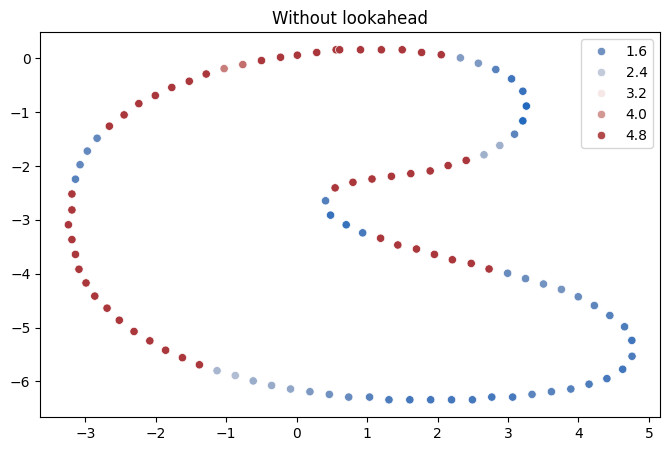

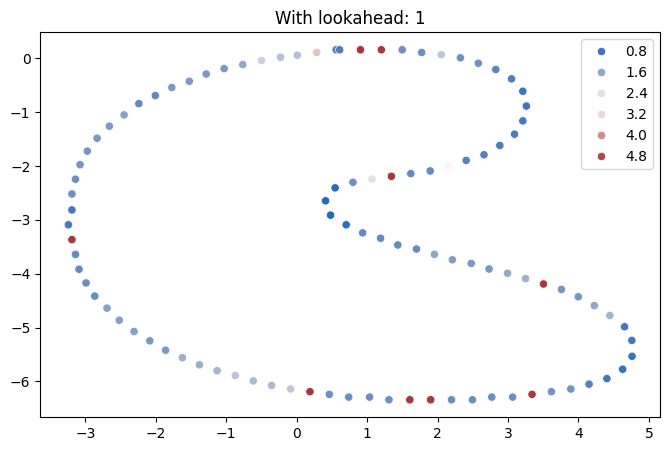

In [93]:


from matplotlib import pyplot as plt
import seaborn as sns

x = [i[0] for i in racing_track]
y = [i[1] for i in racing_track]

# Without lookahead
velocity_no_lookahead = optimal_velocity(track=racing_track,
    min_speed=MIN_SPEED, max_speed=MAX_SPEED, look_ahead_points=0, smoothing_window_size=SMOOTHING_WINDOW_SIZE)

fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.scatterplot(x=x, y=y, hue=velocity_no_lookahead,
                     palette="vlag").set_title("Without lookahead")

fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.scatterplot(x=x, y=y, hue=velocity, palette="vlag").set_title(
    f"With lookahead: {LOOK_AHEAD_POINTS}")




# Calculate distance and optimal time between each racing point


In [72]:

distance_to_prev = []
for i in range(len(racing_track)):
    indexes = circle_indexes(racing_track, i, add_index_1=-1, add_index_2=0)[0:2]
    coords = [racing_track[indexes[0]],racing_track[indexes[1]]]
    dist_to_prev = dist_2_points(x1=coords[0][0], x2=coords[1][0], y1=coords[0][1], y2=coords[1][1])
    distance_to_prev.append(dist_to_prev)
    
time_to_prev = [(distance_to_prev[i]/velocity[i]) for i in range(len(racing_track))]

total_time = sum(time_to_prev)
print(f"Total time for track, if racing line and speeds are followed perfectly: {total_time} s")


Total time for track, if racing line and speeds are followed perfectly: 23.215066832417115 s



# Append everything together and save to .txt file

In [73]:


# Now we have list with columns (x,y,speed,distance,time)
racing_track_everything = []
for i in range(len(racing_track)):
    racing_track_everything.append([racing_track[i][0],
                                    racing_track[i][1],
                                    velocity[i],
                                    time_to_prev[i]])
# Round to 5 decimals
racing_track_everything = np.around(racing_track_everything, 5).tolist()



In [74]:


# Write to txt file
with open(f'optimals_newest_{TRACK_NAME}.txt', 'w') as f:
    f.write("[")
    for line in racing_track_everything:
        f.write("%s" % line)
        if line != racing_track_everything[-1]:
            f.write(",\n")
    f.write("]")



NameError: name 'TRACK_NAME' is not defined